In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
sns.set_style('whitegrid')
sns.set_palette("Set2")

%matplotlib inline

In [7]:
# !pip install seaborn

# Leer los datos

In [30]:
# Datos lucia
df_lu = pd.read_csv("../data/respuestas_lucia.csv")
print(df_lu.shape)

# Datos fede
df_fe = pd.read_csv("../data/respuestas_fede.csv")
print(df_fe.shape)

#globales
marmol = df_fe.loc[df_fe["escuela"] == "Colegio Modelo Mármol"]
mantovani = df_fe.loc[df_fe["escuela"] == "Escuela Nueva Juan Mantovani"]
cant_total = len(df_fe)
cant_marmol = len(marmol)
cant_mantovani = len(mantovani)

(144, 17)
(369, 22)


# Data Lucia, features como filas 

In [5]:
df_lu.head().transpose()

,0,1,2,3,4
timestamp,3/12/2021 19:15:01,3/17/2021 21:12:19,3/18/2021 21:28:35,3/26/2021 22:14:29,4/19/2021 13:40:42
q_edad,10,9,10,9,9
q_genero,f,f,m,f,f
q_donde_compu,a_donde_compu_casa,a_donde_compu_casa,a_donde_compu_casa,a_donde_compu_casa,a_donde_compu_casa
q_que_haces_compu,"a_que_haces_compu_videos, a_que_haces_compu_tarea",a_que_haces_compu_juegos,a_que_haces_compu_videos,"a_que_haces_compu_juegos, a_que_haces_compu_vi...","a_que_haces_compu_juegos, a_que_haces_compu_vi..."
q_donde_aprendiste_compu,a_donde_aprendiste_compu_casa,a_donde_aprendiste_compu_solo,a_donde_aprendiste_compu_escuela,"a_donde_aprendiste_compu_casa, a_donde_aprendi...",a_donde_aprendiste_compu_casa
q_que_celu_usas,a_que_celu_usas_propio,a_que_celu_usas_propio,a_que_celu_usas_propio,a_que_celu_usas_prestado,a_que_celu_usas_propio
q_que_haces_celu,"a_que_haces_celu_chat, a_que_haces_celu_videos...",a_que_haces_celu_redes,a_que_haces_celu_juegos,"a_que_haces_celu_chat, a_que_haces_celu_telefo...",a_que_haces_celu_chat
q_yt,a_yt_1compu,a_yt_1compu,a_yt_muchascompu,a_yt_nose,a_yt_celular
q_acceso_fotos,a_acceso_fotos_yoyotros,a_acceso_fotos_yo,a_acceso_fotos_yo,a_acceso_fotos_yoyotros,a_acceso_fotos_yo


# Data Fede, features como filas 

In [6]:
df_fe.head().transpose()

,0,1,2,3,4
timestamp,11/17/2022 8:35:00,11/17/2022 8:36:12,11/17/2022 8:36:21,11/17/2022 8:36:30,11/17/2022 8:36:39
escuela,Escuela Nueva Juan Mantovani,Escuela Nueva Juan Mantovani,Escuela Nueva Juan Mantovani,Escuela Nueva Juan Mantovani,Escuela Nueva Juan Mantovani
grado,Quinto,Quinto,Quinto,Quinto,Quinto
curso,B,B,B,B,B
edad,10,10,11,10,11
genero,Masculino,Masculino,Masculino,Masculino,Femenino
lugar_computadora,En la escuela,En mi casa,En mi casa,En mi casa,En mi casa
uso_computadora,"Juego juegos, Hago la tarea","Juego juegos, Miro videos en YouTube",Juego juegos,"Juego juegos, Hablo con mis amigos",Hablo con amigos
aprender_computadora,"Me enseñaron en mi casa (mis padres, hermanos ...","Me enseñaron en mi casa (mis padres, hermanos ...",Aprendí solo,"Me enseñaron en mi casa (mis padres, hermanos ...","Me enseñaron en mi casa (mis padres, hermanos ..."
dueño_celular,El mío,El mío,El mío,El mío,El mío


# Descripción del grupo

A continuación se describe el grupo encuestado según distintas variables poblacionales. 


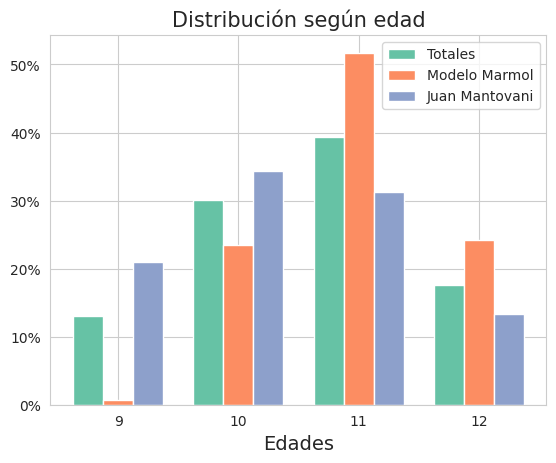

In [94]:
# Distribución según edad
data_total = df_fe["edad"].value_counts(normalize=True).sort_index()
data_marmol = marmol["edad"].value_counts(normalize=True).sort_index()
data_mantovani = mantovani["edad"].value_counts(normalize=True).sort_index()

bar_width = 0.25
br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]
plt.bar(br1,data_total, width=bar_width, label = 'Totales')
plt.bar(br2,data_marmol, width=bar_width, label = 'Modelo Marmol')
plt.bar(br3,data_mantovani, width=bar_width, label = 'Juan Mantovani')

plt.xlabel("Edades", fontsize=14)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución según edad", fontsize=15)
plt.xticks([r + bar_width for r in range(len(data_total))], [id for id in data_total.sort_index().index])
plt.legend()
plt.savefig('1.png')

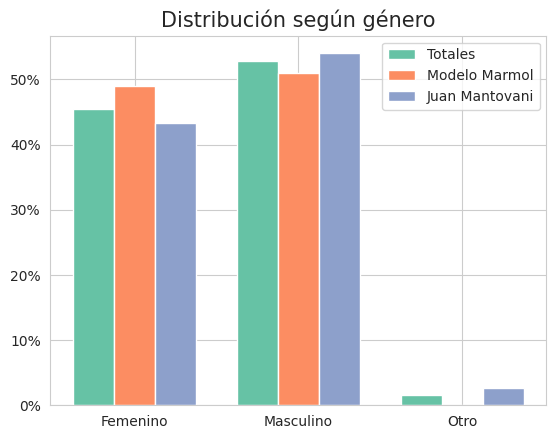

In [95]:
# Distribución según género
data_total = df_fe["genero"].value_counts(normalize=True).sort_index()
data_marmol = marmol["genero"].value_counts(normalize=True).sort_index()
data_mantovani = mantovani["genero"].value_counts(normalize=True).sort_index()

data_marmol["Otro"] = 0.0

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,data_total, width=bar_width, label = 'Totales')
plt.bar(br2,data_marmol, width=bar_width, label = 'Modelo Marmol')
plt.bar(br3,data_mantovani, width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución según género", fontsize=15)
plt.xticks([r + bar_width for r in range(len(data_total))], [id for id in data_total.sort_index().index])
plt.legend()
plt.savefig('2.png')

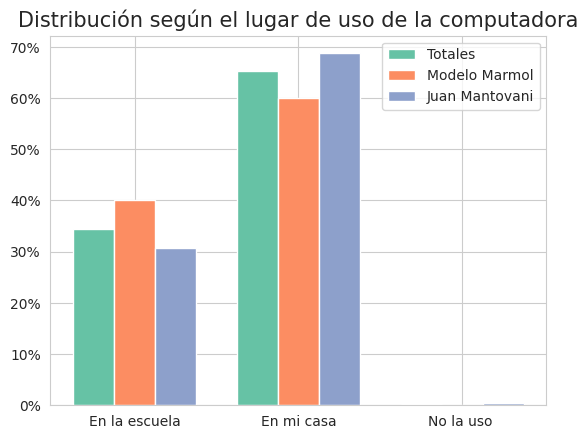

In [96]:
# Lugar de uso de la computadora
data_total = df_fe["lugar_computadora"].value_counts(normalize=True).sort_index()
data_marmol = marmol["lugar_computadora"].value_counts(normalize=True).sort_index()
data_mantovani = mantovani["lugar_computadora"].value_counts(normalize=True).sort_index()

data_marmol["No la uso"] = 0.0

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,data_total, width=bar_width, label = 'Totales')
plt.bar(br2,data_marmol, width=bar_width, label = 'Modelo Marmol')
plt.bar(br3,data_mantovani, width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución según el lugar de uso de la computadora", fontsize=15)
plt.xticks([r + bar_width for r in range(len(data_total))], [id for id in data_total.sort_index().index])
plt.legend()
plt.savefig('3.png')

# Fede
Es un grupo con muchos niñes de 11 años, principalmente en el Modelo Marmol. Con respecto al género, están bien distribuidos en el Mantovani y hay un % mayor de varones en el Modelo Mármol.

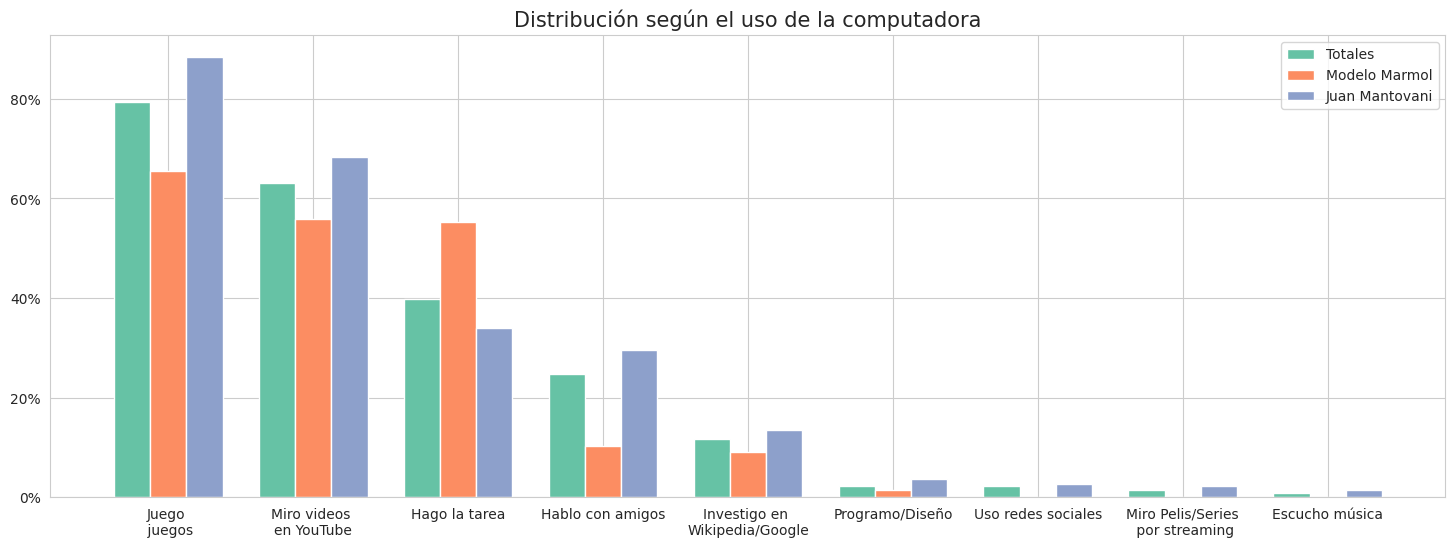

In [100]:
# Uso de la computadora
data_total = df_fe["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)
data_marmol = marmol["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)
data_mantovani = mantovani["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani).sort_values(ascending=False)

for data in data_total.index:
    if data not in data_marmol.index:
        data_marmol[data] = 0.0
    if data not in data_mantovani.index:
        data_mantovani[data] = 0.0

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]


plt.figure(figsize=(18, 6))

labels = ("Juego \n juegos", "Miro videos \nen YouTube", "Hago la tarea", \
            "Hablo con amigos", "Investigo en \nWikipedia/Google", "Programo/Diseño", \
            "Uso redes sociales", "Miro Pelis/Series\n por streaming", "Escucho música\n")

plt.bar(br1,data_total, width=bar_width, label = 'Totales')
plt.bar(br2,data_marmol, width=bar_width, label = 'Modelo Marmol')
plt.bar(br3,data_mantovani, width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución según el uso de la computadora", fontsize=15)
plt.xticks([r + bar_width for r in range(len(data_total))], labels)
plt.legend()
plt.savefig('4.png')

# Lucia
Queda claro que la mayor parte de los participantes utilizan la computadora en su casa. Siendo que tanto este año como el anterior vivimos en un contexto de pandemia, este resultado no resulta sorprendente.

Podemos destacar que la mayor parte de los niños y niñas parecieran contar con una computadora en sus hogares, siendo tan solo uno de ellos quien respondió que no poseía una.

También les preguntamos para qué utilizan más comúnmente la computadora. Les dimos la posibilidad de marcar más de una opción dentro de una serie de respuestas y al mismo tiempo, dejamos espacio disponible para poder completar con otras actividades que no estuvieran dentro de las que les habíamos propuesto.

Por otro lado, la mayoría utiliza la computadora para jugar juegos, siendo las siguientes actividades más usuales mirar videos en YouTube, realizar videollamadas utilizando Skype, Meet o Zoom y realizar actividades escolares. Nuevamente, esto tiene sentido siendo que durante todo el 2020 en Argentina hubo clases de manera virtual.

# Fede
Un tercio de los participantes usan la computadora mayormente en la escuela y el resto en su casa.

En cuanto a los usos comunes vemos una leve diferencia entre colegios. Jugar juegos y Youtube son las opciones más elegidas; Hay diferencias marcadas entre los porcentajes de chicos que usan la computadora para hacer la tarea, hablar con amigos y jugar juegos entre colegios. También vemos que en ambos colegios un porcentaje cerca del 10% selecciona la nueva opción de Investigar en Wikipedia/Google según sus intereses particulares.

`Podríamos comparar usos de la computadora entre cursos y ver que cambios se notan entre ellos`

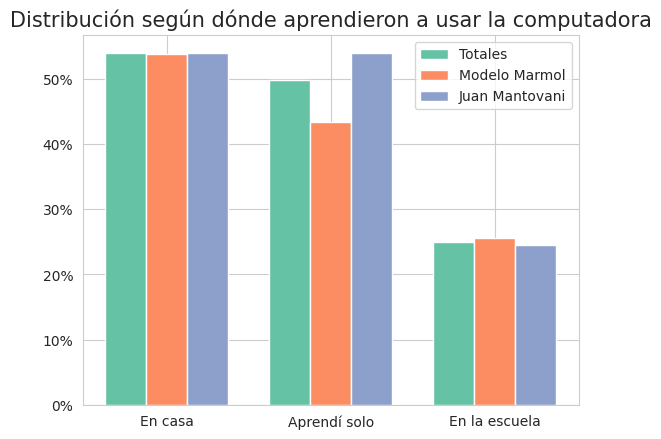

In [97]:
# Donde aprendiste a uisar la computadora
data_total = df_fe["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)
data_marmol = marmol["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)
data_mantovani = mantovani["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani).sort_values(ascending=False)

for data in data_total.index:
    if data not in data_marmol.index:
        data_marmol[data] = 0.0
    if data not in data_mantovani.index:
        data_mantovani[data] = 0.0

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

labels = ("En casa", "Aprendí solo", "En la escuela")

plt.bar(br1,data_total, width=bar_width, label = 'Totales')
plt.bar(br2,data_marmol, width=bar_width, label = 'Modelo Marmol')
plt.bar(br3,data_mantovani, width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución según dónde aprendieron a usar la computadora", fontsize=15)
plt.xticks([r + bar_width for r in range(len(data_total))], labels)
plt.legend()
plt.savefig('5.png')

# Fede
En cuanto a la forma en la que aprendieron a usar la computadora, podemos ver que las opciones más elegidas son _"Me enseñaron en mi casa (mis padres, hermanos u otro familiar)"_ y _"Aprendí solo"_. Nuevamente queda para la siguiente iteracion `comparar respuestas entre cursos y ver que cambios se notan entre ellos`

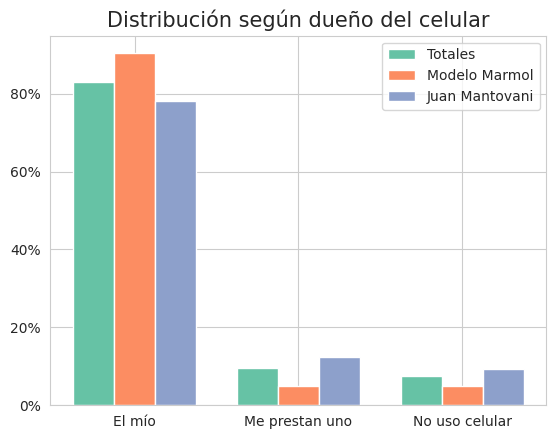

In [103]:
# Distribución según dueño del celular
data_total = df_fe["dueño_celular"].value_counts(normalize=True).sort_index()
data_marmol = marmol["dueño_celular"].value_counts(normalize=True).sort_index()
data_mantovani = mantovani["dueño_celular"].value_counts(normalize=True).sort_index()

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,data_total, width=bar_width, label = 'Totales')
plt.bar(br2,data_marmol, width=bar_width, label = 'Modelo Marmol')
plt.bar(br3,data_mantovani, width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución según dueño del celular", fontsize=15)
plt.xticks([r + bar_width for r in range(len(data_total))], [id for id in data_total.sort_index().index])
plt.legend()
plt.savefig('6.png')

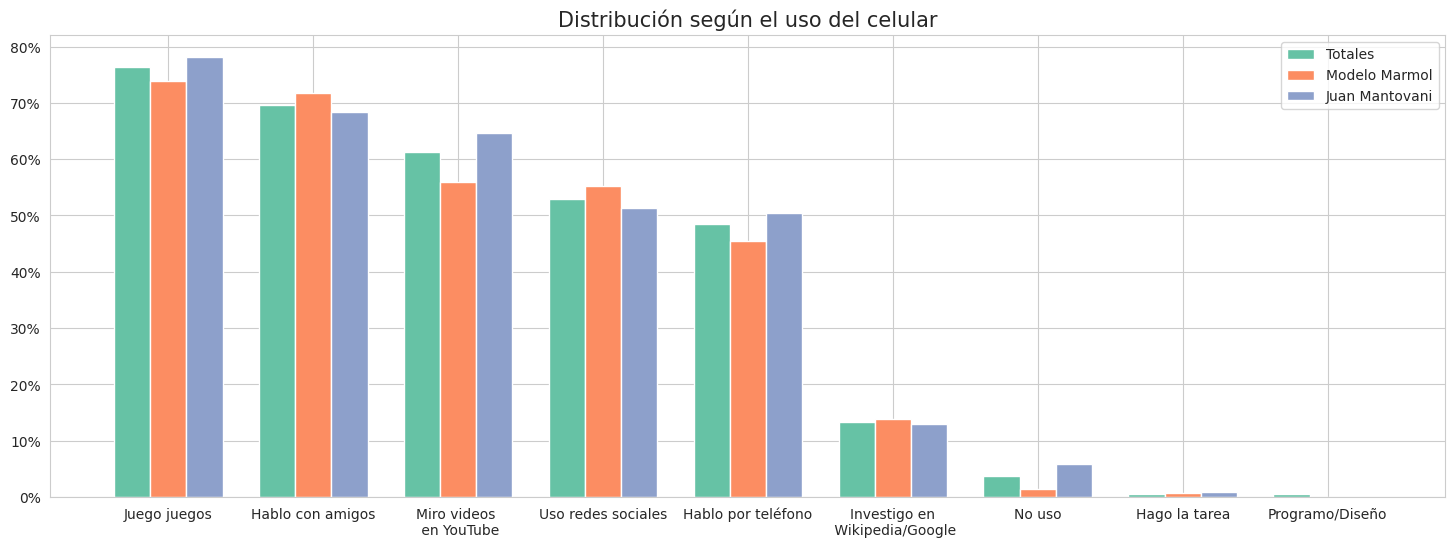

In [110]:
# Distribución uso del celular
data_total = df_fe["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)
data_marmol = marmol["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)
data_mantovani = mantovani["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani).sort_values(ascending=False)

for data in data_total.index:
    if data not in data_marmol.index:
        data_marmol[data] = 0.0
    if data not in data_mantovani.index:
        data_mantovani[data] = 0.0

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

labels = ("Juego juegos", "Hablo con amigos", "Miro videos \n en YouTube", "Uso redes sociales", \
           "Hablo por teléfono", "Investigo en\n Wikipedia/Google", "No uso", "Hago la tarea", "Programo/Diseño\n")

plt.figure(figsize=(18, 6))

plt.bar(br1,data_total, width=bar_width, label = 'Totales')
plt.bar(br2,data_marmol, width=bar_width, label = 'Modelo Marmol')
plt.bar(br3,data_mantovani, width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución según el uso del celular", fontsize=15)
plt.xticks([r + bar_width for r in range(len(data_total))], labels)
plt.legend()
plt.savefig('7.png')

# Lucia
Al indagar en la forma en que los chicos y chicas utilizan los celulares nos encontramos con que la gran mayoría cuenta con un dispositivo propio.

La actividad más realizada es nuevamente jugar juegos, pero se suma con mucha importancia también el chat (utilizando aplicaciones de mensajería tales como Whatsapp, Telegram, etc) y mirar videos en YouTube.

Es llamativo que haya aparecido _"Llamadas telefónicas"_ como una actividad de una importancia considerable, aunque cabe preguntarse si habría que haber pedido que especifiquen si se referían videollamadas utilizando las aplicaciones anteriormente mencionadas, y en tal caso la actividad "Chat" cobraría aún más relevancia.

Dentro de _"Redes Sociales"_ se incluyen ejemplos como TikTok, Instagram y Facebook, aunque no les pedimos que especifiquen ninguna en particular. Sin embargo, sabemos por la consulta realizada previamente a la confección de la encuesta que realizamos a los referentes pedagógicos de la Fundación Sadosky que trabajan para el Plan Ceibal, que la red social elegida por sobre las otras es en estos momentos TikTok.

Por último, cabe destacar que _"Actividades creativas"_ no fue una opción propuesta por nosotros en el cuestionario (tanto en esta pregunta como en la relacionada a las actividades realizadas con la computadora), sino que fue agregada por los chicos y chicas al momento de completar la encuesta. Dentro de este grupo, agrupamos respuestas que se referían a la edición de videos y fotos (tal vez para compartir en aplicaciones tales como TikTok o Instagram), escuchar música y escribir historias.

# Fede
Vemos diferencia respecto a los porcentajes de chicos que no usan celular o les prestan uno. `De nuevo esto puedde ser por sus distintas edades`. Igualmente los dos nuevos colegios repiten un alto porcentaje de chicos con celu propio.

Los porcentajes parecen calcados entre colegios y con los de Lucia. La unica diferencia es al igual que en el uso de la computadora el pequeño porcentaje que utiliza el celular para investigar intereses personales